# Does resampling reproduce on the Slowloris attack data?

Hasanin et al. (2019, J. Big Data) reported that on their severely imbalanced **SlowlorisBig** set, oversampling and undersampling *improved* performance (unlike their first dataset, where, once uncertainty was shown, they did not). SlowlorisBig is not published, so we rebuild a comparable **Slowloris-vs-benign** task from the public CICIDS2017 set (UNB CIC, Wednesday capture) and ask whether the improvement reproduces.

Fixed Random Forest and XGBoost; **baseline | class-weight | random oversampling | SMOTE | random undersampling** on the same stratified 70/30 splits over 5 seeds. Metrics are threshold-free (ROC-AUC, average precision, Brier, mean predicted probability). Because the methods share seeds, the comparison against baseline is **paired** (same split), so the delta's dispersion is meaningful.

In [1]:
import pickle, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
os.makedirs('../figures', exist_ok=True)

with open('../models/cicids-slowloris/results.pkl', 'rb') as f:
    res = pickle.load(f)
runs = pd.DataFrame(res['runs'])
meta = res['meta']
LEARNERS = ['rf', 'xgb']
METHODS = ['baseline', 'class_weight', 'ros', 'smote', 'rus']
meta

{'n': 205796, 'pos': 5796, 'features': 68}

## Comparison, with paired deltas vs baseline

`d_roc` / `d_ap` are the mean of the per-seed differences from the baseline on the same split (± std). If the band crosses zero, the method is not distinguishable from doing nothing.

In [2]:
rows = []
for ln in LEARNERS:
    base = runs[(runs.learner == ln) & (runs.method == 'baseline')].set_index('seed')
    for m in METHODS:
        sub = runs[(runs.learner == ln) & (runs.method == m)].set_index('seed')
        d_roc = sub['roc'] - base['roc']
        d_ap = sub['ap'] - base['ap']
        rows.append({
            'learner': ln, 'method': m,
            'roc': f"{sub['roc'].mean():.4f}±{sub['roc'].std():.4f}",
            'ap': f"{sub['ap'].mean():.4f}±{sub['ap'].std():.4f}",
            'd_roc': round(d_roc.mean(), 4), 'd_roc_sd': round(d_roc.std(), 4),
            'd_ap': round(d_ap.mean(), 4), 'd_ap_sd': round(d_ap.std(), 4),
            'brier': f"{sub['brier'].mean():.1e}",
            'mean_prob': round(sub['mean_prob'].mean(), 4),
        })
table = pd.DataFrame(rows).set_index(['learner', 'method'])
table

roc             ap   d_roc  d_roc_sd    d_ap  \
learner method                                                                 
rf      baseline      0.9994±0.0007  0.9988±0.0013  0.0000    0.0000  0.0000   
        class_weight  0.9996±0.0006  0.9992±0.0012  0.0002    0.0001  0.0004   
        ros           0.9996±0.0006  0.9992±0.0012  0.0002    0.0001  0.0005   
        smote         0.9996±0.0006  0.9992±0.0012  0.0002    0.0001  0.0004   
        rus           0.9998±0.0003  0.9989±0.0010  0.0004    0.0004  0.0001   
xgb     baseline      0.9999±0.0002  0.9997±0.0005  0.0000    0.0000  0.0000   
        class_weight  0.9998±0.0004  0.9996±0.0007 -0.0001    0.0001 -0.0001   
        ros           0.9999±0.0003  0.9997±0.0006 -0.0000    0.0000 -0.0000   
        smote         0.9998±0.0003  0.9997±0.0005 -0.0000    0.0001 -0.0000   
        rus           0.9999±0.0002  0.9994±0.0008  0.0000    0.0001 -0.0003   

                      d_ap_sd    brier  mean_prob  
learner method                                     
rf      baseline       0.0000  1.4e-04     0.0282  
        class_weight   0.0002  1.4e-04     0.0283  
        ros            0.0002  1.3e-04     0.0282  
        smote          0.0002  1.4e-04     0.0284  
        rus            0.0003  8.4e-04     0.0327  
xgb     baseline       0.0000  1.1e-04     0.0281  
        class_weight   0.0002  1.1e-04     0.0281  
        ros            0.0000  1.2e-04     0.0281  
        smote          0.0000  1.2e-04     0.0281  
        rus            0.0003  5.5e-04     0.0292

## Paired delta vs baseline (ROC-AUC and average precision)

Each bar is a method's mean change from the baseline on the same splits, with ±1 std. Everything sits on top of the zero line within its error bar: no method beats the baseline.

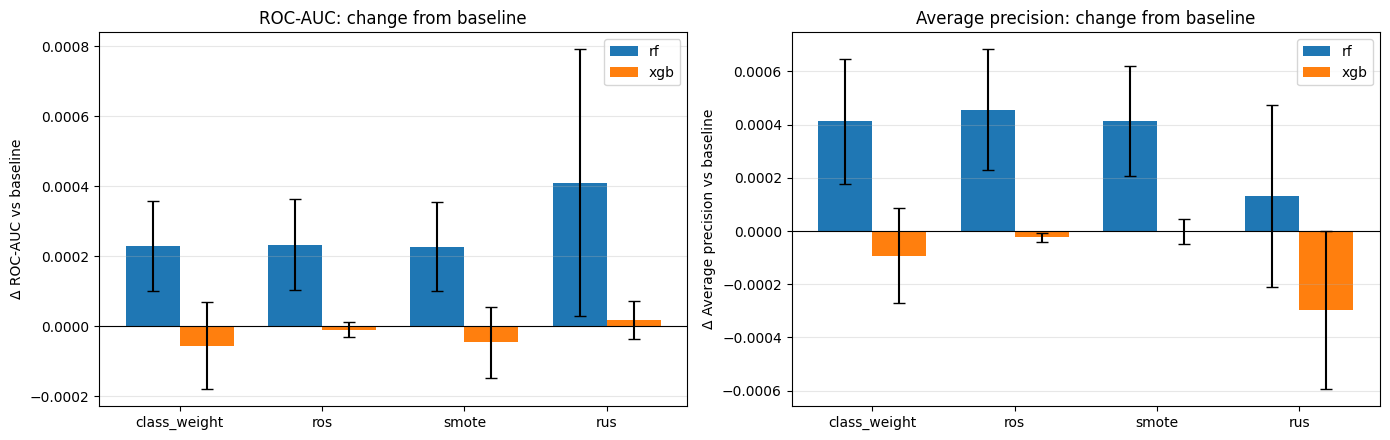

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
methods_x = [m for m in METHODS if m != 'baseline']
for ax, metric, title in [(axes[0], 'roc', 'ROC-AUC'), (axes[1], 'ap', 'Average precision')]:
    width = 0.38
    for i, ln in enumerate(LEARNERS):
        base = runs[(runs.learner == ln) & (runs.method == 'baseline')].set_index('seed')
        means, sds = [], []
        for m in methods_x:
            sub = runs[(runs.learner == ln) & (runs.method == m)].set_index('seed')
            d = sub[metric] - base[metric]
            means.append(d.mean()); sds.append(d.std())
        xs = np.arange(len(methods_x)) + (i - 0.5) * width
        ax.bar(xs, means, width, yerr=sds, capsize=4, label=ln)
    ax.axhline(0, color='k', lw=0.8)
    ax.set_xticks(np.arange(len(methods_x))); ax.set_xticklabels(methods_x)
    ax.set_ylabel(f'Δ {title} vs baseline'); ax.set_title(f'{title}: change from baseline')
    ax.legend(); ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout(); plt.savefig('../figures/cicids_delta.png', dpi=150, bbox_inches='tight')
plt.show()

## Calibration

The one method with a real effect is random undersampling, and it is a *harm*: it inflates the predicted probabilities above the true rate (dotted), exactly as in the speed experiment. The others stay calibrated.

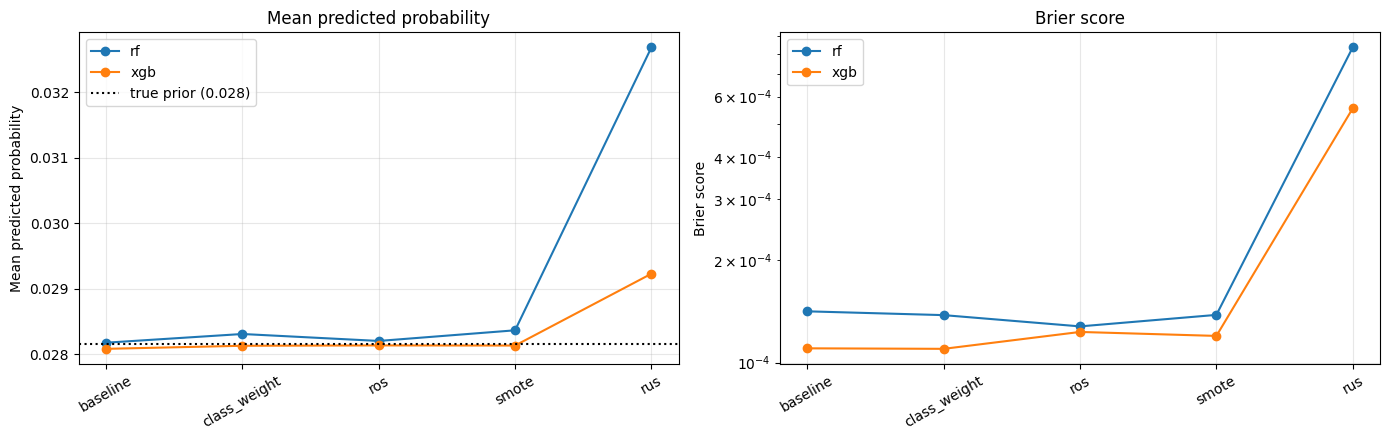

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
true_p = meta['pos'] / meta['n']
for a, metric, title, logy in [(ax[0], 'mean_prob', 'Mean predicted probability', False),
                               (ax[1], 'brier', 'Brier score', True)]:
    for ln in LEARNERS:
        g = runs[runs.learner == ln].groupby('method')[metric].mean().reindex(METHODS)
        a.plot(METHODS, g.values, 'o-', label=ln)
    if metric == 'mean_prob':
        a.axhline(true_p, ls=':', color='k', label=f'true prior ({true_p:.3f})')
    if logy: a.set_yscale('log')
    a.set_ylabel(title); a.set_title(title); a.tick_params(axis='x', rotation=30)
    a.legend(); a.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('../figures/cicids_calibration.png', dpi=150, bbox_inches='tight')
plt.show()

## A paired statistical test (the question Sole raised)

Because the methods share seeds, each can be tested against the baseline with a paired t-test on the five per-seed differences, Holm-corrected across the four methods (the correction for running several tests at once). This is a within-dataset demonstration; across the full dataset suite the headline test would be Friedman + Holm with the baseline as control (Demsar 2006). The point to watch is effect size: a difference can be flagged 'significant' merely because it is consistent across seeds, while being practically nil on a near-ceiling baseline.

In [5]:
from scipy.stats import ttest_rel

def holm(pvals):
    p = np.asarray(pvals); order = np.argsort(p); m = len(p); run = 0.0
    adj = np.empty(m)
    for rank, idx in enumerate(order):
        run = max(run, (m - rank) * p[idx]); adj[idx] = min(run, 1.0)
    return adj

stat_rows = []
for ln in LEARNERS:
    base = runs[(runs.learner == ln) & (runs.method == 'baseline')].set_index('seed').sort_index()
    recs, praw = [], []
    for m in [x for x in METHODS if x != 'baseline']:
        sub = runs[(runs.learner == ln) & (runs.method == m)].set_index('seed').sort_index()
        d = sub['roc'] - base['roc']
        p = ttest_rel(sub['roc'], base['roc']).pvalue
        praw.append(p)
        recs.append({'learner': ln, 'method': m, 'd_roc': round(float(d.mean()), 4), 'p_raw': round(float(p), 3)})
    for r, a in zip(recs, holm(praw)):
        r['p_holm'] = round(float(a), 3)
        stat_rows.append(r)
pd.DataFrame(stat_rows).set_index(['learner', 'method'])

d_roc  p_raw  p_holm
learner method                             
rf      class_weight  0.0002  0.016   0.063
        ros           0.0002  0.016   0.063
        smote         0.0002  0.016   0.063
        rus           0.0004  0.074   0.074
xgb     class_weight -0.0001  0.371   1.000
        ros          -0.0000  0.348   1.000
        smote        -0.0000  0.373   1.000
        rus           0.0000  0.493   1.000

## Conclusion

**No reproduction.** On CICIDS2017 Slowloris-vs-benign the no-resampling baseline is already near-perfect (RF ROC 0.9994 / AP 0.9988; XGBoost 0.9999 / 0.9997). Class-weighting, random oversampling, SMOTE and random undersampling all land within ±0.0006 of the baseline on paired splits — within the seed-to-seed noise — and XGBoost class-weight is marginally *worse*. So the improvement Hasanin et al. reported on SlowlorisBig does not reproduce here; it joins the no-effect pile.

**Random undersampling harms calibration.** The one consistent effect is that RUS inflates the predicted probabilities (RF Brier 8.4e-04 vs 1.4e-04; mean predicted probability 0.033 vs a true 0.028), the same overprediction we see when undersampling without the prior-restoring weights.

**Caveat: a near-ceiling baseline is a weak discrimination test.** Slowloris is highly separable from benign with the standard flow features, so there is little room for any method to help. That both explains the null result and sharpens the dispersion point: a small 'improvement' reported on a near-perfect baseline *without dispersion* — as in the SlowlorisBig source — is most likely noise. A genuinely discriminating test would need a deliberately harder version of the task (fewer features, a temporal split, or a noisier label).